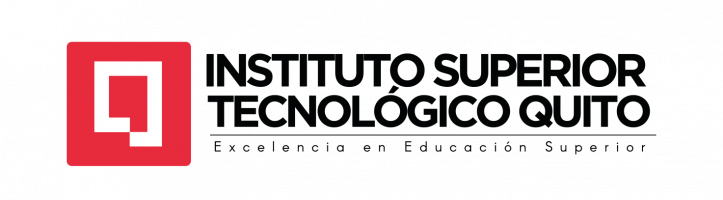

## Seleccion De Atributos 2

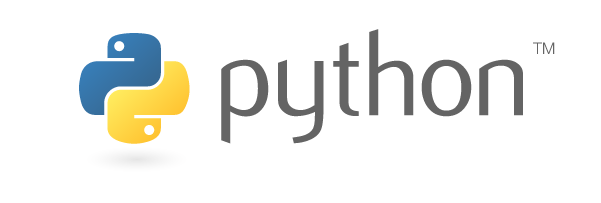

*Byron Armando Melo Aguilar*

*[Enlace a Github](https://github.com/ByronMN911/Machine-Learning-II/blob/main/pr%C3%A1cticas/Parcial%20I/Programa6_SeleccionAtributos2.ipynb)*

In [1]:
# Se importa numpy para la generación y manipulación de los datos numéricos.
import numpy as np

# Se importa matplotlib.pyplot para poder graficar la relación entre cada atributo y la variable
# objetivo.
import matplotlib.pyplot as plt

# Se importan f_regression y mutual_info_regression desde sklearn.feature_selection. Ambas
# funciones evalúan qué tan relacionado está cada atributo con la variable objetivo en un problema
# de regresión, pero mediante criterios distintos: f_regression se basa en la correlación lineal,
# mientras que mutual_info_regression estima la dependencia estadística general entre variables,
# sin asumir que la relación deba ser lineal.
from sklearn.feature_selection import f_regression, mutual_info_regression

In [2]:
# Se fija la semilla del generador aleatorio de numpy en 42 para que los datos generados sean
# siempre los mismos en cada ejecución, garantizando resultados reproducibles.
np.random.seed(42)

# Se genera la matriz de atributos X con 1000 observaciones y 3 columnas, cada una con valores
# aleatorios distribuidos de manera uniforme entre 0 y 1. Estas tres columnas representarán tres
# atributos candidatos cuya relevancia se evaluará más adelante.
X = np.random.rand(1000, 3)
print(X)
print(np.shape(X))

[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]
 ...
 [0.80000348 0.55270708 0.39655368]
 [0.13171503 0.86529576 0.15727321]
 [0.30978786 0.29004553 0.87141403]]
(1000, 3)


In [3]:
# Se construye la variable objetivo y de forma artificial, haciéndola depender explícitamente de
# la primera columna de X (relación lineal, mediante X[:, 0]) y de la segunda columna de X
# (relación no lineal, mediante una función seno aplicada a X[:, 1]).
# La tercera columna, X[:, 2], no interviene en absoluto en el cálculo de y, por lo que se espera
# que ambos métodos de evaluación la identifiquen como poco o nada relevante.
# Finalmente se añade un término de ruido aleatorio (0.1 * np.random.randn(1000)) para simular la
# variabilidad que suele existir en datos reales.
y = X[:, 0] + np.sin(6 * np.pi * X[:, 1]) + 0.1 * np.random.randn(1000)

In [4]:
# Se calcula el estadístico F para cada uno de los tres atributos de X respecto a la variable
# objetivo y. Un valor de F más alto indica una relación lineal más fuerte entre el atributo
# correspondiente y el objetivo. La función devuelve también los p-valores asociados, que en este
# caso se descartan asignándolos a la variable _.
f_test, _ = f_regression(X, y)

# Se normalizan los valores del estadístico F dividiendo entre el máximo obtenido, de modo que
# todos los resultados queden en una escala comparable entre 0 y 1, facilitando su interpretación
# y su posterior visualización.
f_test /= np.max(f_test)

In [5]:
# Se calcula la información mutua entre cada atributo de X y la variable objetivo y. A diferencia
# del F-test, este criterio no asume una relación lineal, por lo que es capaz de detectar también
# dependencias más complejas, como la relación senoidal introducida en la segunda columna.
mi = mutual_info_regression(X, y)

# Al igual que con el F-test, se normalizan los valores de información mutua dividiendo entre el
# máximo, para poder comparar ambos criterios en una misma escala.
mi /= np.max(mi)

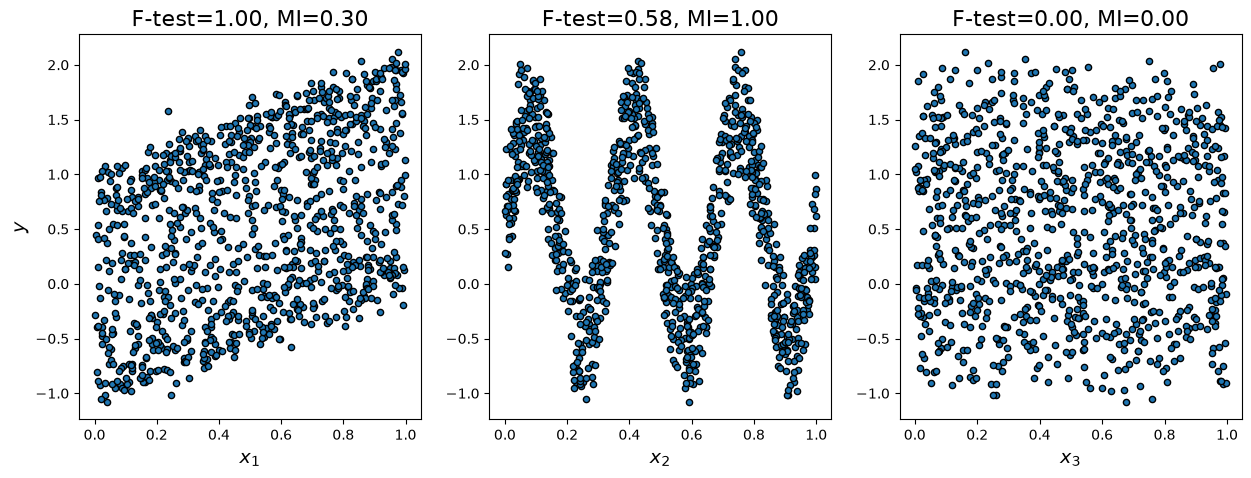

In [6]:
# Se crea una figura con tamaño 15x5 pulgadas para alojar los tres subgráficos, uno por cada
# atributo de X.
plt.figure(figsize=(15, 5))

# Se recorre cada uno de los tres atributos para graficar su relación con la variable objetivo.
for i in range(3):
    # Se selecciona la posición del subgráfico correspondiente al atributo actual, dentro de una
    # cuadrícula de 1 fila y 3 columnas.
    plt.subplot(1, 3, i + 1)

    # Se dibuja un diagrama de dispersión entre el atributo i y la variable objetivo y, lo que
    # permite observar visualmente el tipo de relación existente (lineal, no lineal o inexistente).
    plt.scatter(X[:, i], y, edgecolor='black', s=20)
    plt.xlabel("$x_{}$".format(i + 1), fontsize=14)

    # Solo se añade la etiqueta del eje y en el primer subgráfico, para evitar repetirla
    # innecesariamente en los tres paneles.
    if i == 0:
        plt.ylabel("$y$", fontsize=14)

    # Se añade como título de cada subgráfico el valor normalizado del F-test y de la información
    # mutua correspondientes a ese atributo, permitiendo comparar de un vistazo ambos criterios de
    # relevancia para cada una de las tres columnas.
    plt.title("F-test={:.2f}, MI={:.2f}".format(f_test[i], mi[i]), fontsize=16)

plt.show()